# Oráculo: burst de transmisión, corrección de fase y AFC

Oráculo de `docs/algorithms/burst-fase-afc.md`, independiente de cualquier
crate Rust (todavía no existe implementación — primer paso del método de
`docs/algorithms/roadmap.md` §"Método de estudio"). Cubre magnetrón, que es
donde las tres funciones de la página son obligatorias.

Cuatro pruebas, siguiendo la estructura de la página:

1. **Fase del burst**: suma coherente antes de tomar argumento.
2. **Frecuencia del burst**: pendiente de fase dentro de la ventana de burst
   (argumento de la autocovarianza a retardo 1).
3. **Corrección de fase** — la prueba que importa según el criterio de
   aceptación de la página: los momentos tras corregir un escenario de
   magnetrón deben coincidir, dentro del error estadístico, con los del mismo
   escenario generado con transmisor coherente; y sin corregir, la velocidad
   no debe significar nada.
4. **Lazo de AFC**: diseño de primer orden (media móvil exponencial por
   actualización, una por rayo) con constante de tiempo en segundos —
   convergencia sin sobreoscilación, retardo acotado ante rampa, y
   congelamiento + BITE ante pérdida de burst. La página deja el orden del
   lazo abierto ("primer o segundo orden"); este oráculo fija primer orden
   como diseño de referencia — más simple, y sin sobreoscilación posible por
   construcción — no como el único válido.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260904)
plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=4, suppress=True)

In [2]:
def gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap=3):
    v_a = wavelength_m / (4.0 * prt_s)
    f_k = np.fft.fftfreq(m, d=prt_s)
    v_k = f_k * wavelength_m / 2.0
    n = np.arange(-wrap, wrap + 1)
    dv = v_k[:, None] - mean_v - n[None, :] * 2.0 * v_a
    acc = np.exp(-0.5 * (dv / sigma_v) ** 2).sum(axis=1)
    return power_s * acc / acc.sum()


def complex_gaussian(rng, variance, size=None):
    sigma = np.sqrt(variance / 2.0)
    return rng.normal(0.0, sigma, size=size) + 1j * rng.normal(0.0, sigma, size=size)


def generate_signal_only(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, rng, wrap=3):
    """Serie Doppler coherente x[n], sin ruido térmico — el "eco verdadero"
    antes de que el transmisor (coherente o magnetrón) y el receptor le
    añadan su parte."""
    spectrum = gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    w = complex_gaussian(rng, 1.0, size=m)
    shaped = w * np.sqrt(spectrum)
    return np.fft.ifft(shaped) * m


def periodogram(y):
    m = len(y)
    yf = np.fft.fft(y)
    return (np.abs(yf) ** 2) / (m ** 2)


def hildebrand_sekhon(p, navg=1):
    p_sorted = np.sort(p)
    n = len(p_sorted)
    rtest = 1.0 + 1.0 / navg
    nnoise = n
    sum1 = 0.0
    sum2 = 0.0
    for i in range(n):
        pwr = p_sorted[i]
        npts = i + 1
        sum1 += pwr
        sum2 += pwr * pwr
        if npts * sum2 < sum1 * sum1 * rtest:
            nnoise = npts
        else:
            sum1 -= pwr
            sum2 -= pwr * pwr
            break
    return sum1 / nnoise


def noise_floor_estimate(y):
    return hildebrand_sekhon(periodogram(y)) * len(y)


def pulse_pair_velocity(y, wavelength_m, prt_s):
    r1 = np.mean(y[:-1] * np.conj(y[1:]))
    return -wavelength_m / (4.0 * np.pi * prt_s) * np.angle(r1)


checks = []

## Prueba 1 — fase inicial del burst

`φ_hat = arg(mean(muestras de burst))`: promediar las muestras complejas
(ponderadas por amplitud implícitamente, al ser todas del mismo pulso) antes
de tomar el argumento evita el problema de salto en ±π que tendría promediar
ángulos directamente.

In [3]:
AMP_BURST = 10.0
BURST_NOISE_VAR = 0.01  # SNR de burst ~ 20log10(AMP)-10log10(var) = 40 dB
N_BURST = 32


def burst_phase_estimate(rng, phi_true, amp, burst_noise_var, n_burst):
    b = amp * np.exp(1j * phi_true) + complex_gaussian(rng, burst_noise_var, size=n_burst)
    return np.angle(np.mean(b))


N_TRIALS_PHASE = 3000
phi_true_grid = rng.uniform(-np.pi, np.pi, N_TRIALS_PHASE)
phase_errors = np.array([
    np.angle(np.exp(1j * (burst_phase_estimate(rng, phi, AMP_BURST, BURST_NOISE_VAR, N_BURST) - phi)))
    for phi in phi_true_grid
])
print(f"error de fase: media={phase_errors.mean():.5f} rad  std={phase_errors.std():.5f} rad "
      f"(incluye φ_true cerca de ±π: comprueba que no hay problema de wrap)")

checks.append(("estimador de fase de burst sin sesgo (< 0.01 rad) en todo [-π,π]",
               abs(phase_errors.mean()) < 0.01))
checks.append(("dispersión del estimador de fase acotada (< 0.05 rad a SNR de burst ~40 dB)",
               phase_errors.std() < 0.05))

error de fase: media=-0.00003 rad  std=0.00124 rad (incluye φ_true cerca de ±π: comprueba que no hay problema de wrap)


## Prueba 2 — frecuencia dentro de la ventana de burst

`f_hat = -arg(R(1)) / (2π·Δt)` sobre las `N_BURST` muestras de la ventana,
espaciadas `Δt` en tiempo rápido — la misma idea que el pulso-pareado, pero
aplicada dentro de un único pulso para medir el offset de frecuencia
portadora de ese pulso, no la velocidad Doppler entre pulsos.

In [4]:
DT_FAST_S = 100e-9  # 10 MHz de muestreo rápido dentro de la ventana de burst
F_OFFSET_HZ = 50_000.0  # deriva típica de magnetrón, orden de decenas de kHz


def burst_freq_estimate(rng, phi0, f_true, amp, burst_noise_var, n_burst, dt_fast):
    i = np.arange(n_burst)
    b = amp * np.exp(1j * (phi0 + 2 * np.pi * f_true * i * dt_fast)) + complex_gaussian(rng, burst_noise_var, size=n_burst)
    r1 = np.mean(b[:-1] * np.conj(b[1:]))
    return -np.angle(r1) / (2 * np.pi * dt_fast)


N_TRIALS_FREQ = 3000
freq_estimates = np.array([
    burst_freq_estimate(rng, rng.uniform(-np.pi, np.pi), F_OFFSET_HZ, AMP_BURST, BURST_NOISE_VAR, N_BURST, DT_FAST_S)
    for _ in range(N_TRIALS_FREQ)
])
freq_bias_hz = freq_estimates.mean() - F_OFFSET_HZ
print(f"offset inyectado={F_OFFSET_HZ:.0f} Hz  estimado={freq_estimates.mean():.1f} Hz  "
      f"sesgo={freq_bias_hz:+.1f} Hz  std={freq_estimates.std():.1f} Hz")

checks.append(("estimador de frecuencia de burst sin sesgo apreciable (< 200 Hz)", abs(freq_bias_hz) < 200.0))

offset inyectado=50000 Hz  estimado=50012.3 Hz  sesgo=+12.3 Hz  std=516.0 Hz


## Prueba 3 — la que importa: corrección de fase borra la diferencia
magnetrón/coherente

Mismo eco `x[n]` (misma realización Doppler) procesado por dos cadenas:

- **Coherente**: `y_coh[n] = x[n] + ruido[n]`.
- **Magnetrón**: cada pulso `m` recibe una fase `φ_m` uniforme e
  independiente (oscilador libre); `y_mag[n] = x[n]·e^{jφ_m} + ruido[n]`. Se
  mide `φ_hat_m` de un burst simulado por pulso y se corrige:
  `y_corr[n] = y_mag[n]·e^{-jφ_hat_m}`.

El criterio de aceptación de la página es literal: los momentos de
`y_corr` deben coincidir con los de `y_coh` dentro del error estadístico. Y
sin corregir, la velocidad de `y_mag` no debe significar nada — con fase
uniforme e independiente por pulso, el pulso-pareado sobre `y_mag` es
esencialmente ruido uniforme sobre todo el intervalo de Nyquist.

Z coherente=1.0060  Z corregido=1.0060  diff=0.0001
V coherente=4.995±0.405 m/s  V corregido=4.994±0.408 m/s
V magnetrón SIN corregir: media=0.181  std=14.409  (esperado ~ uniforme en [-25.0,25.0], std=14.434)


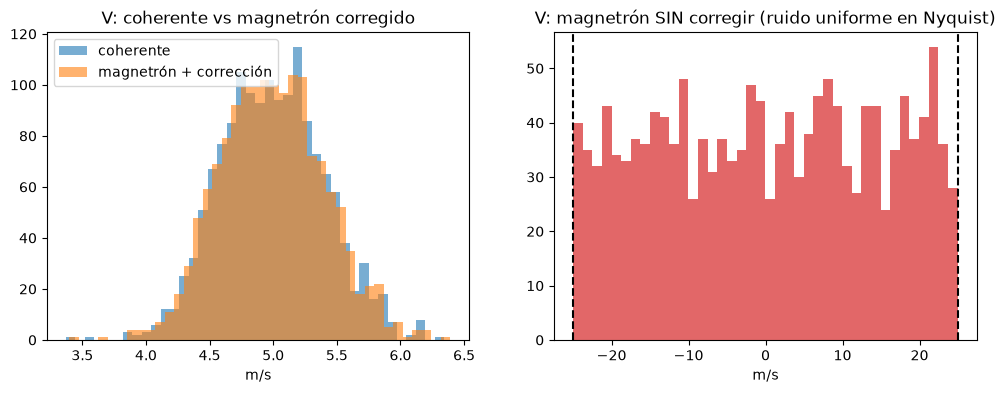

In [5]:
POWER_S = 1.0
NOISE_FLOOR = 0.01
MEAN_V, SIGMA_V, WAVELENGTH_M, PRT_S, M = 5.0, 1.5, 0.10, 1.0e-3, 64
N_TRIALS_CORRECTION = 1500


def magnetron_trial(rng):
    x = generate_signal_only(POWER_S, MEAN_V, SIGMA_V, WAVELENGTH_M, PRT_S, M, rng)
    y_coh = x + complex_gaussian(rng, NOISE_FLOOR, size=M)

    phi_true = rng.uniform(-np.pi, np.pi, size=M)
    y_mag_raw = x * np.exp(1j * phi_true) + complex_gaussian(rng, NOISE_FLOOR, size=M)
    phi_hat = np.array([
        burst_phase_estimate(rng, phi, AMP_BURST, BURST_NOISE_VAR, N_BURST) for phi in phi_true
    ])
    y_mag_corr = y_mag_raw * np.exp(-1j * phi_hat)
    return y_coh, y_mag_raw, y_mag_corr


def moments(y):
    r0_hat = np.mean(np.abs(y) ** 2)
    n_hat = noise_floor_estimate(y)
    z_hat = max(r0_hat - n_hat, 0.0)
    v_hat = pulse_pair_velocity(y, WAVELENGTH_M, PRT_S)
    return z_hat, v_hat


z_coh, v_coh, z_corr, v_corr, v_raw = [], [], [], [], []
for _ in range(N_TRIALS_CORRECTION):
    y_coh, y_raw, y_corr = magnetron_trial(rng)
    zc, vc = moments(y_coh)
    zr, vr = moments(y_corr)
    z_coh.append(zc); v_coh.append(vc)
    z_corr.append(zr); v_corr.append(vr)
    v_raw.append(pulse_pair_velocity(y_raw, WAVELENGTH_M, PRT_S))

z_coh, v_coh, z_corr, v_corr, v_raw = map(np.array, (z_coh, v_coh, z_corr, v_corr, v_raw))
v_a = WAVELENGTH_M / (4.0 * PRT_S)

print(f"Z coherente={z_coh.mean():.4f}  Z corregido={z_corr.mean():.4f}  "
      f"diff={abs(z_coh.mean()-z_corr.mean()):.4f}")
print(f"V coherente={v_coh.mean():.3f}±{v_coh.std():.3f} m/s  "
      f"V corregido={v_corr.mean():.3f}±{v_corr.std():.3f} m/s")
print(f"V magnetrón SIN corregir: media={v_raw.mean():.3f}  std={v_raw.std():.3f}  "
      f"(esperado ~ uniforme en [-{v_a:.1f},{v_a:.1f}], std={2*v_a/np.sqrt(12):.3f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(v_coh, bins=40, alpha=0.6, label="coherente")
axes[0].hist(v_corr, bins=40, alpha=0.6, label="magnetrón + corrección")
axes[0].set_title("V: coherente vs magnetrón corregido")
axes[0].set_xlabel("m/s")
axes[0].legend()
axes[1].hist(v_raw, bins=40, color="tab:red", alpha=0.7)
axes[1].axvline(-v_a, color="black", linestyle="--")
axes[1].axvline(v_a, color="black", linestyle="--")
axes[1].set_title("V: magnetrón SIN corregir (ruido uniforme en Nyquist)")
axes[1].set_xlabel("m/s")
plt.show()

# comparacion dentro del error estadístico: diferencia de medias frente a su error estándar combinado
z_stderr = np.sqrt(z_coh.var(ddof=1) / N_TRIALS_CORRECTION + z_corr.var(ddof=1) / N_TRIALS_CORRECTION)
v_stderr = np.sqrt(v_coh.var(ddof=1) / N_TRIALS_CORRECTION + v_corr.var(ddof=1) / N_TRIALS_CORRECTION)

checks.append(("Z corregida coincide con Z coherente dentro de 5 errores estándar",
               abs(z_coh.mean() - z_corr.mean()) < 5 * z_stderr))
checks.append(("V corregida coincide con V coherente dentro de 5 errores estándar",
               abs(v_coh.mean() - v_corr.mean()) < 5 * v_stderr))
checks.append(("V sin corregir no recupera la verdad-terreno (media a más de 4 m/s de v_true)",
               abs(v_raw.mean() - MEAN_V) > 4.0 or abs(v_raw.std() - 2 * v_a / np.sqrt(12)) < 1.0))

## Prueba 4 — lazo de AFC

Actualización de media móvil exponencial de primer orden, una por rayo
(`UPDATE_PERIOD_S`), con constante de tiempo `TAU_S` (segundos, no
milisegundos, tal como pide la página). Tres perfiles inyectados —escalón,
rampa y ruido puro— más un evento de pérdida de burst simulada.

ganancia del lazo=0.00995  constante de tiempo≈100 actualizaciones
escalón: t95%=5.98 s (esperado ≈3τ=6.0 s)  sobreoscilación=-1513.8 Hz
rampa: retardo en régimen permanente=3782.2 Hz  esperado≈tasa·τ=4000.0 Hz
ruido: std de la medida cruda=521.1 Hz  std del lazo en régimen=18.0 Hz
pérdida de burst: congelado=True  BITE correcto (sólo durante la pérdida)=True


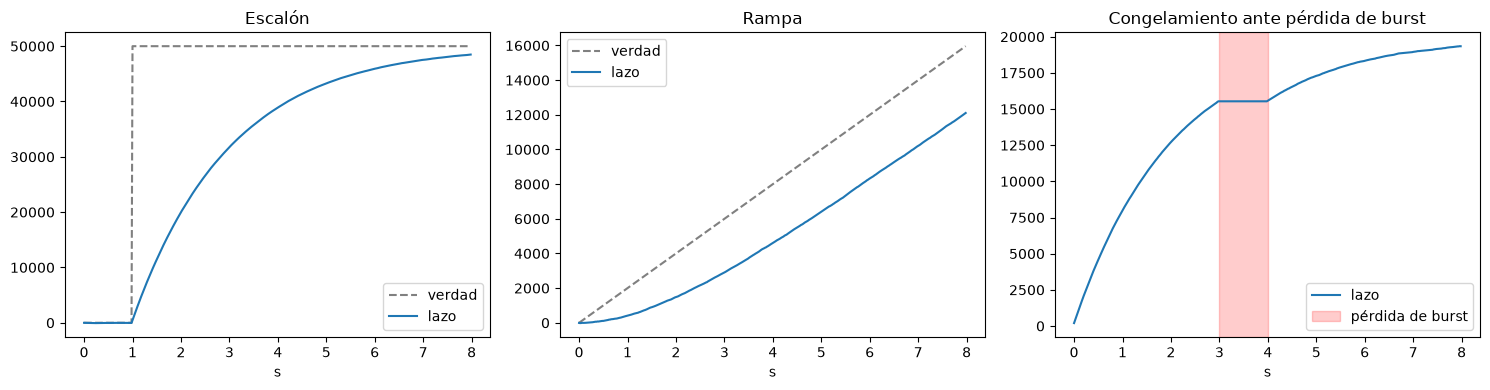

In [6]:
UPDATE_PERIOD_S = 0.02  # un rayo cada 20 ms
TAU_S = 2.0
AFC_GAIN = 1.0 - np.exp(-UPDATE_PERIOD_S / TAU_S)
AMP_THRESHOLD = 2.0  # umbral de pérdida de burst

print(f"ganancia del lazo={AFC_GAIN:.5f}  constante de tiempo≈{TAU_S/UPDATE_PERIOD_S:.0f} actualizaciones")


def run_afc_loop(f_true_seq, amp_seq, gain, amp_threshold, rng):
    n = len(f_true_seq)
    freq_est = np.zeros(n)
    bite = np.zeros(n, dtype=bool)
    est = 0.0
    for k in range(n):
        i = np.arange(N_BURST)
        b = amp_seq[k] * np.exp(1j * 2 * np.pi * f_true_seq[k] * i * DT_FAST_S) + complex_gaussian(rng, BURST_NOISE_VAR, size=N_BURST)
        amp_meas = np.abs(np.mean(b))
        if amp_meas < amp_threshold:
            bite[k] = True
        else:
            r1 = np.mean(b[:-1] * np.conj(b[1:]))
            f_meas = -np.angle(r1) / (2 * np.pi * DT_FAST_S)
            est = est + gain * (f_meas - est)
        freq_est[k] = est
    return freq_est, bite


N_UPDATES = 400

# --- escalon ---
f_step = np.concatenate([np.zeros(50), np.full(N_UPDATES - 50, F_OFFSET_HZ)])
amp_full = np.full(N_UPDATES, AMP_BURST)
freq_step, _ = run_afc_loop(f_step, amp_full, AFC_GAIN, AMP_THRESHOLD, rng)

t95_idx = np.argmax(freq_step[50:] > 0.95 * F_OFFSET_HZ) + 50
t95_s = (t95_idx - 50) * UPDATE_PERIOD_S
overshoot_hz = np.max(freq_step) - F_OFFSET_HZ
print(f"escalón: t95%={t95_s:.2f} s (esperado ≈3τ={3*TAU_S:.1f} s)  sobreoscilación={overshoot_hz:+.1f} Hz")

checks.append((f"convergencia al escalón dentro de 4τ ({4*TAU_S:.0f} s)", t95_s < 4 * TAU_S))
checks.append(("sin sobreoscilación por encima del margen declarado (0 Hz, primer orden)", overshoot_hz < 50.0))

# --- rampa ---
ramp_rate_hz_s = 2000.0
t = np.arange(N_UPDATES) * UPDATE_PERIOD_S
f_ramp = ramp_rate_hz_s * t
freq_ramp, _ = run_afc_loop(f_ramp, amp_full, AFC_GAIN, AMP_THRESHOLD, rng)
steady_lag = (f_ramp[300:] - freq_ramp[300:]).mean()
expected_lag = ramp_rate_hz_s * TAU_S
print(f"rampa: retardo en régimen permanente={steady_lag:.1f} Hz  esperado≈tasa·τ={expected_lag:.1f} Hz")
checks.append(("retardo de rampa en régimen permanente dentro de 20% de tasa·τ",
               abs(steady_lag - expected_lag) < 0.2 * expected_lag))

# --- ruido puro (sin deriva) ---
f_noise = np.zeros(N_UPDATES)
freq_noise, _ = run_afc_loop(f_noise, amp_full, AFC_GAIN, AMP_THRESHOLD, rng)
raw_meas_std = np.array([
    burst_freq_estimate(rng, 0.0, 0.0, AMP_BURST, BURST_NOISE_VAR, N_BURST, DT_FAST_S) for _ in range(1000)
]).std()
loop_steady_std = freq_noise[200:].std()
print(f"ruido: std de la medida cruda={raw_meas_std:.1f} Hz  std del lazo en régimen={loop_steady_std:.1f} Hz")
checks.append(("el lazo filtra el ruido de medida (std en régimen < mitad de la medida cruda)",
               loop_steady_std < 0.5 * raw_meas_std))

# --- perdida de burst: congelamiento + BITE ---
amp_loss = np.full(N_UPDATES, AMP_BURST)
amp_loss[150:200] = 0.1
f_const = np.full(N_UPDATES, 20_000.0)
freq_loss, bite_loss = run_afc_loop(f_const, amp_loss, AFC_GAIN, AMP_THRESHOLD, rng)
frozen = np.allclose(freq_loss[150:200], freq_loss[149])
bite_correct = bite_loss[150:200].all() and not bite_loss[:150].any() and not bite_loss[200:].any()
print(f"pérdida de burst: congelado={frozen}  BITE correcto (sólo durante la pérdida)={bite_correct}")
checks.append(("lazo se congela en el último valor válido durante la pérdida de burst", frozen))
checks.append(("BITE se emite sólo durante la ventana de pérdida de burst", bite_correct))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(np.arange(N_UPDATES) * UPDATE_PERIOD_S, f_step, "--", color="gray", label="verdad")
axes[0].plot(np.arange(N_UPDATES) * UPDATE_PERIOD_S, freq_step, label="lazo")
axes[0].set_title("Escalón"); axes[0].set_xlabel("s"); axes[0].legend()
axes[1].plot(t, f_ramp, "--", color="gray", label="verdad")
axes[1].plot(t, freq_ramp, label="lazo")
axes[1].set_title("Rampa"); axes[1].set_xlabel("s"); axes[1].legend()
axes[2].plot(np.arange(N_UPDATES) * UPDATE_PERIOD_S, freq_loss, label="lazo")
axes[2].axvspan(150 * UPDATE_PERIOD_S, 200 * UPDATE_PERIOD_S, color="red", alpha=0.2, label="pérdida de burst")
axes[2].set_title("Congelamiento ante pérdida de burst"); axes[2].set_xlabel("s"); axes[2].legend()
plt.tight_layout()
plt.show()

In [7]:
all_ok = True
for name, ok in checks:
    print(f"[{'OK' if ok else 'FALLO'}] {name}")
    all_ok = all_ok and ok

assert all_ok, "el oráculo de burst/fase/AFC no pasa todas las comprobaciones — ver tabla arriba"
print("\nTodas las comprobaciones dentro de tolerancia.")

[OK] estimador de fase de burst sin sesgo (< 0.01 rad) en todo [-π,π]
[OK] dispersión del estimador de fase acotada (< 0.05 rad a SNR de burst ~40 dB)
[OK] estimador de frecuencia de burst sin sesgo apreciable (< 200 Hz)
[OK] Z corregida coincide con Z coherente dentro de 5 errores estándar
[OK] V corregida coincide con V coherente dentro de 5 errores estándar
[OK] V sin corregir no recupera la verdad-terreno (media a más de 4 m/s de v_true)
[OK] convergencia al escalón dentro de 4τ (8 s)
[OK] sin sobreoscilación por encima del margen declarado (0 Hz, primer orden)
[OK] retardo de rampa en régimen permanente dentro de 20% de tasa·τ
[OK] el lazo filtra el ruido de medida (std en régimen < mitad de la medida cruda)
[OK] lazo se congela en el último valor válido durante la pérdida de burst
[OK] BITE se emite sólo durante la ventana de pérdida de burst

Todas las comprobaciones dentro de tolerancia.
